# Crop Disease Diagnosis — Evaluation Pipeline

This notebook evaluates two trained models on a held-out test set of Nepali crop images:

1. **Baseline CNN** — `prathamshrestha69/CNN-baseline` (PyTorch, trained from scratch)
2. **SmolVLM-256M + LoRA adapter** — `w4ashabii/SmolVLM256M_CropDisease` (generative vision-language model)

For each model the notebook:

- Samples exactly 100 images per crop class from a local `test_dataset/` directory
- Computes Accuracy, Macro Precision, Macro Recall, and Macro F1-Score
- Plots a labelled confusion matrix
- Logs every misclassified image (true label(s) vs. predicted label(s) vs. file path) for the Error Analysis section of the report

**Crop *and* disease.** Folder names (`test_dataset/tomato/img.jpg`)
only ever tell us the crop. Section 4a downloads `labels_registry.jsonl` (published alongside the
image zips in the same dataset repo), which has a `disease` field for every image,
and Section 8 parses **both** a crop and a disease out of SmolVLM's answer. The
Baseline CNN has no disease-detection capability at all (its output layer only ever
predicts a crop index), so disease evaluation is SmolVLM-only — Section 11 reports
one disease confusion matrix per crop.

**Note on class count:** `cherry`, `peach`, `pepper`, and `strawberry` were
dropped from the dataset for having too few images, so evaluation now runs on
**5 classes**: `apple`, `grape`, `maize`, `potato`, `tomato`. The CNN checkpoint
itself still has 9 output nodes (it was trained before those classes were
removed) — Section 3 explains how the notebook handles that distinction so the
confusion matrix doesn't show empty rows/columns for classes with zero
ground-truth samples.

**Test data:** Section 4 below downloads the test images automatically from the
`w4ashabii/nepali_crop_data` dataset repo on Hugging Face — no manual upload
needed. If you'd rather supply your own folder instead (e.g. a different or
trimmed test set), skip Section 4 and upload a `test_dataset/` folder to the
Colab file browser, or mount Google Drive, using this structure:

```
test_dataset/
├── apple/
│   ├── img001.jpg
│   └── ...
├── grape/
├── maize/
├── potato/
└── tomato/
```

Each subfolder name must match a crop class exactly. Folders with fewer than 100 images, or missing folders, are handled gracefully (a warning is printed and evaluation proceeds with the available images). Note that skipping Section 4 also means skipping Section 4a, so bring your own `(crop, filename) -> disease` lookup if you go this route — the disease confusion matrices need it.


## 1. Install Dependencies

In [1]:
# NOTE: deliberately NOT reinstalling torch/torchvision here. Colab ships
# them pre-installed and version-matched to its CUDA build (and to the
# pre-installed torchaudio); reinstalling only torch/torchvision via pip can
# desync that match and break the whole transformers import chain with a
# confusing "CUDA version mismatch" / "ModuleNotFoundError: AutoProcessor" error.
!pip install -q -U transformers peft accelerate huggingface_hub scikit-learn matplotlib seaborn pandas pillow "torchao>=0.16.0"
# After this finishes, use Runtime > Restart session, then re-run from the top.
# Colab keeps the older transformers loaded in memory until you restart.

## 2. Imports and Reproducibility Setup

In [2]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download
from transformers import AutoProcessor
# Class was renamed across transformers versions; try the current name first.
try:
    from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq
except ImportError:
    from transformers import AutoModelForVision2Seq
from peft import PeftModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 3. Configuration

**Two class lists, not one — this matters.**

`cherry`, `peach`, `pepper`, and `strawberry` were dropped from the dataset for
having too few images, so the **test set** now only has 5 classes. But the
already-trained CNN checkpoint (`baseline_cnn.pt`) still has **9 output nodes**
— it was trained before those classes were removed, and its final layer's shape
is fixed by the saved weights. Passing only 5 classes to `BaselineCNN(...)`
would make `model.load_state_dict(...)` fail with a shape mismatch, and mapping
`argmax` output to a class name would silently point at the wrong crop.

So:
- **`MODEL_CLASSES`** — all 9, in the exact order the CNN was trained on. Used
  only to correctly decode which index the CNN's output layer corresponds to.
- **`EVAL_CLASSES`** — the 5 classes actually present in the current test set.
  Used for sampling, and as the ground-truth axis for metrics and the
  confusion matrix.

If the CNN model is later *retrained* on only 5 classes, `MODEL_CLASSES` should
be updated to match (and would then equal `EVAL_CLASSES`).

In [3]:
# All 9 classes the CNN checkpoint was originally trained on (alphabetical
# order, matching torchvision.datasets.ImageFolder's class-to-index mapping).
# Do NOT trim this list unless the CNN itself gets retrained with fewer
# output classes — it must match the checkpoint's fc2 layer shape.
MODEL_CLASSES = [
    "apple", "cherry", "grape", "maize", "peach",
    "pepper", "potato", "strawberry", "tomato",
]

# Classes actually present in the current test set (cherry, peach, pepper,
# and strawberry were removed for having too little data). This is the list
# used for sampling and for computing metrics / the confusion matrix.
EVAL_CLASSES = ["apple", "grape", "maize", "potato", "tomato"]

N_SAMPLES_PER_CLASS = 100
IMG_SIZE = 128  # matches the CNN training notebook

# If you ran the "Download the Test Dataset from Hugging Face" cell above,
# the test split lands here automatically:
TEST_DATASET_DIR = Path("/content/training_data/test")

# If instead you manually uploaded a test_dataset/ folder (see structure in
# Section 1), point this at that folder instead, e.g.:
# TEST_DATASET_DIR = Path("/content/test_dataset")
# TEST_DATASET_DIR = Path("/content/drive/MyDrive/test_dataset")

CNN_REPO_ID = "prathamshrestha69/CNN-baseline"
CNN_FILENAME = "baseline_cnn.pt"

VLM_BASE_MODEL = "HuggingFaceTB/SmolVLM-256M-Instruct"
VLM_ADAPTER_REPO = "w4ashabii/SmolVLM256M_CropDisease"

# Ground-truth crop *and* disease labels for every image live in this file,
# published alongside the image zips in the same dataset repo. One JSON object
# per line: {"image": "<split>/<crop>/<filename>", "split": ..., "crop": ...,
# "disease": ..., "label_source": ...}. Folder names only ever gave us the
# crop — this registry is what makes disease evaluation possible at all.
LABELS_REGISTRY_REPO_ID = "w4ashabii/nepali_crop_data"
LABELS_REGISTRY_FILENAME = "labels_registry.jsonl"

# Text SmolVLM uses for the "no disease" / "can't tell" cases (see Section 8).
# Kept as constants so the parsing logic and the ground-truth registry values
# it's compared against can't silently drift apart.
DISEASE_HEALTHY_LABEL = "healthy"
DISEASE_UNKNOWN_LABEL = "unspecified"

RESULTS_DIR = Path("/content/eval_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Model output classes (fixed by checkpoint):", MODEL_CLASSES)
print("Evaluation classes (current test set):", EVAL_CLASSES)


Model output classes (fixed by checkpoint): ['apple', 'cherry', 'grape', 'maize', 'peach', 'pepper', 'potato', 'strawberry', 'tomato']
Evaluation classes (current test set): ['apple', 'grape', 'maize', 'potato', 'tomato']


## 4. Download the Test Dataset from Hugging Face

The source images are not stored in the GitHub repo — they live in a separate
Hugging Face **dataset** repo, `w4ashabii/nepali_crop_data`, split across multiple
zip parts under a `zips/` folder. Each part extracts into `train/`, `val/`, and
`test/` subfolders, with one folder per crop inside each split.

This cell lists every zip part in the repo (rather than assuming a single
filename) and extracts all of them, so every crop class ends up populated under
`test/`. Skip this cell entirely if you already have a `test_dataset/` folder
uploaded locally in the structure described in Section 1.

In [4]:
import zipfile
from huggingface_hub import HfApi, hf_hub_download

DATASET_REPO_ID = "w4ashabii/nepali_crop_data"
DATASET_EXTRACT_TO = Path("/content/training_data")
DATASET_EXTRACT_TO.mkdir(parents=True, exist_ok=True)

api = HfApi()
try:
    repo_files = api.list_repo_files(DATASET_REPO_ID, repo_type="dataset")
except Exception as exc:
    raise RuntimeError(f"Failed to list files in dataset repo '{DATASET_REPO_ID}': {exc}")

zip_files = sorted(f for f in repo_files if f.startswith("zips/") and f.endswith(".zip"))
if not zip_files:
    raise RuntimeError(
        f"No zip files found under 'zips/' in '{DATASET_REPO_ID}'. "
        "Check the repo's Files tab for the current data layout."
    )
print("Found zip parts:", zip_files)

for zip_name in zip_files:
    try:
        local_zip = hf_hub_download(repo_id=DATASET_REPO_ID, repo_type="dataset", filename=zip_name)
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(DATASET_EXTRACT_TO)
        print(f"Extracted: {zip_name}")
    except Exception as exc:
        print(f"[WARNING] Failed to download/extract {zip_name}: {exc}")

print("\nData ready at:", DATASET_EXTRACT_TO)
print("\nTop-level split folders found:")
for split_dir in sorted(DATASET_EXTRACT_TO.glob("*")):
    if split_dir.is_dir():
        print(f"  {split_dir}")

TEST_SPLIT_DIR = DATASET_EXTRACT_TO / "test"
if TEST_SPLIT_DIR.is_dir():
    print("\nCrop folders found under test/:")
    for cls_dir in sorted(TEST_SPLIT_DIR.glob("*")):
        if cls_dir.is_dir():
            n_images = len(list(cls_dir.glob("*")))
            print(f"  {cls_dir.name:12s}: {n_images} files")
else:
    print(f"\n[WARNING] No 'test' folder found at {TEST_SPLIT_DIR}. "
          "Check the extracted folder structure above.")

Found zip parts: ['zips/dataset_part_000.zip']


zips/dataset_part_000.zip: reconstructing file:   0%|          |  0.00B / 1.52GB            

zips/dataset_part_000.zip: downloading bytes:           |  0.00B            

Extracted: zips/dataset_part_000.zip

Data ready at: /content/training_data

Top-level split folders found:
  /content/training_data/test
  /content/training_data/train
  /content/training_data/val

Crop folders found under test/:
  apple       : 666 files
  grape       : 666 files
  maize       : 666 files
  potato      : 666 files
  tomato      : 666 files


## 4a. Download Disease Ground-Truth Labels

Folder names only tell us the **crop** (`test_dataset/tomato/img.jpg` → crop is
`tomato`). They say nothing about disease, so a confusion matrix built purely
from folder-derived labels can only ever measure crop classification — that's
why disease accuracy has been invisible until now.

The dataset repo also publishes `labels_registry.jsonl`, one JSON object per
image with both `crop` and `disease` fields, e.g.:

```json
{"image": "train/grape/019bc14cdd5841cdbee440b99067f39e.jpg", "split": "train", "crop": "grape", "disease": "black rot", "label_source": "foldername"}
```

**It isn't a standalone file at the repo root** — it's bundled inside one of
the `zips/` parts downloaded in Section 4, so it lands automatically at
`training_data/labels_registry.jsonl` (next to `test/`, `train/`, `val/`) once
that cell has run. This cell picks it up from there, with a Hugging Face Hub
lookup as a fallback in case a future zip layout drops it from the archive.

We key the resulting lookup on `(crop, filename)` rather than the full `image`
path because Section 4b backfills short test classes by *copying* files from
`val/`/`train/` into `test/` — the physical folder a file lives in can change,
but its filename doesn't, so this key stays valid regardless of which split a
file was originally logged under. (Verified unique across the whole registry —
zero `(crop, filename)` collisions.)


In [5]:
import json


def locate_labels_registry(extract_dir, repo_id, filename):
    """
    labels_registry.jsonl is bundled inside one of the zips/ parts (it lands
    next to test/, train/, val/ once Section 4 has extracted everything), not
    published as a standalone file at the dataset repo root — so a plain
    hf_hub_download(filename=...) call 404s with RemoteEntryNotFoundError.

    Look for it on disk first (searching recursively, since which zip part it
    ends up in isn't guaranteed). Only fall back to the Hub if it's genuinely
    missing locally: first via a direct hf_hub_download (in case a future
    version of the dataset does publish it standalone), then by searching the
    repo's full file listing for anything matching the filename anywhere in
    the repo (in case it lives under a subfolder like zips/).
    """
    local_matches = sorted(Path(extract_dir).rglob(filename))
    if local_matches:
        print(f"Found {filename} already extracted at: {local_matches[0]}")
        return local_matches[0]

    print(f"{filename} not found under {extract_dir} yet — trying the Hugging Face Hub directly.")
    try:
        return Path(hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=filename))
    except Exception as exc:
        print(f"[WARNING] Direct download of '{filename}' failed: {exc}")

    print(f"Searching the full '{repo_id}' file listing for '{filename}'...")
    api = HfApi()
    repo_files = api.list_repo_files(repo_id, repo_type="dataset")
    candidates = [f for f in repo_files if f.endswith(filename)]
    if not candidates:
        raise FileNotFoundError(
            f"Could not find '{filename}' anywhere under {extract_dir}, as a standalone "
            f"file in '{repo_id}', or nested inside it. Re-run Section 4 to make sure all "
            "zip parts extracted successfully, or check the repo's Files tab for the "
            "current location of the labels registry."
        )
    remote_path = candidates[0]
    print(f"Found it in the repo listing at: {remote_path}")
    return Path(hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=remote_path))


labels_registry_path = locate_labels_registry(
    DATASET_EXTRACT_TO, LABELS_REGISTRY_REPO_ID, LABELS_REGISTRY_FILENAME
)

# (crop, filename) -> disease
DISEASE_LOOKUP = {}
with open(labels_registry_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        record = json.loads(line)
        filename = record["image"].split("/")[-1]
        DISEASE_LOOKUP[(record["crop"], filename)] = record["disease"]

print(f"Loaded {len(DISEASE_LOOKUP)} (crop, filename) -> disease entries from {labels_registry_path.name}")

# Per-crop disease vocabulary actually observed in the registry. Used later to
# snap the VLM's free-text disease mention back to a known label instead of
# trusting whatever substring it happened to generate.
DISEASE_VOCAB_BY_CROP = {}
for (crop, _filename), disease in DISEASE_LOOKUP.items():
    DISEASE_VOCAB_BY_CROP.setdefault(crop, set()).add(disease)

print("\\nDisease vocabulary by crop (from registry):")
for crop in MODEL_CLASSES:
    diseases = sorted(DISEASE_VOCAB_BY_CROP.get(crop, []))
    print(f"  {crop:12s}: {diseases}")


Found labels_registry.jsonl already extracted at: /content/training_data/labels_registry.jsonl
Loaded 47489 (crop, filename) -> disease entries from labels_registry.jsonl
\nDisease vocabulary by crop (from registry):
  apple       : ['black rot', 'cedar apple rust', 'healthy', 'leaf curl', 'leaf spot', 'rust', 'scab', 'unspecified']
  cherry      : ['healthy', 'powdery mildew', 'unspecified']
  grape       : ['anthracnose', 'black rot', 'blight', 'healthy', 'leaf spot', 'unspecified']
  maize       : ['anthracnose', 'blight', 'common rust', 'gray leaf spot', 'healthy', 'leaf spot', 'northern leaf blight', 'rust']
  peach       : ['bacterial spot', 'healthy', 'rot', 'unspecified']
  pepper      : ['bacterial spot', 'gray leaf spot', 'healthy', 'leaf curl', 'leaf spot', 'septoria leaf spot', 'unspecified']
  potato      : ['early blight', 'healthy', 'late blight']
  strawberry  : ['healthy', 'rot', 'unspecified']
  tomato      : ['bacterial spot', 'early blight', 'gray leaf spot', 'healt

## 4b. Backfill Missing/Short Test Classes from the Validation Split

Some classes came out of the `test/` split with too few images (or none at
all) after extraction — this is what caused the empty rows in the earlier
confusion matrix. This cell tops up any short class up to
`N_SAMPLES_PER_CLASS` images by copying additional images from `val/` (and
`train/` as a fallback if `val/` still doesn't have enough), without touching
or duplicating any image already present in `test/`.

**Methodological caveat worth stating explicitly in the report:** images
copied in from `val/` were not originally held out as test data — some may
have influenced early stopping / checkpoint selection during training. Any
class backfilled this way should be flagged in the report as evaluated on a
"validation-augmented" test set rather than a purely held-out one, since this
can make its reported accuracy slightly optimistic compared to classes that
had enough genuine test images already.

In [6]:
import shutil

SOURCE_SPLITS_PRIORITY = ["val", "train"]  # fallback order if val/ also comes up short


def backfill_missing_test_classes(base_dir, class_names, n_per_class=100, seed=42):
    """
    Tops up any class in test/ that has fewer than n_per_class images by
    copying additional images from val/ (falling back to train/) until it
    reaches n_per_class, or until no more source images are available.
    Existing test/ images are never removed or duplicated.
    """
    rng = random.Random(seed)
    base_dir = Path(base_dir)
    test_dir = base_dir / "test"
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    backfilled_classes = []

    for cls in class_names:
        cls_test_dir = test_dir / cls
        cls_test_dir.mkdir(parents=True, exist_ok=True)
        existing = [f for f in cls_test_dir.iterdir() if f.suffix.lower() in valid_ext]
        shortfall = n_per_class - len(existing)

        if shortfall <= 0:
            print(f"{cls:12s}: already has {len(existing)} test images, no backfill needed.")
            continue

        existing_names = {f.name for f in existing}
        n_backfilled = 0
        for split in SOURCE_SPLITS_PRIORITY:
            if n_backfilled >= shortfall:
                break
            src_dir = base_dir / split / cls
            if not src_dir.is_dir():
                continue
            candidates = [
                f for f in src_dir.iterdir()
                if f.suffix.lower() in valid_ext and f.name not in existing_names
            ]
            if not candidates:
                continue
            n_take = min(shortfall - n_backfilled, len(candidates))
            for f in rng.sample(candidates, n_take):
                shutil.copy2(f, cls_test_dir / f.name)
                existing_names.add(f.name)
            n_backfilled += n_take
            print(f"  Backfilled {n_take} images for '{cls}' from {split}/")

        total_now = len(list(cls_test_dir.iterdir()))
        status = "OK" if total_now >= n_per_class else "STILL SHORT"
        print(f"{cls:12s}: test now has {total_now} images ({status})")
        if n_backfilled > 0:
            backfilled_classes.append(cls)

    return backfilled_classes


backfilled_classes = backfill_missing_test_classes(
    DATASET_EXTRACT_TO, MODEL_CLASSES, N_SAMPLES_PER_CLASS, seed=SEED
)

if backfilled_classes:
    print(f"\nClasses topped up from val/train: {backfilled_classes}")
    print("Remember to flag these as validation-augmented test data in the report.")
else:
    print("\nNo classes needed backfilling.")

# Now that every class should have data, evaluate against the full label set.
EVAL_CLASSES = MODEL_CLASSES

apple       : already has 666 test images, no backfill needed.
  Backfilled 100 images for 'cherry' from train/
cherry      : test now has 100 images (OK)
grape       : already has 666 test images, no backfill needed.
maize       : already has 666 test images, no backfill needed.
  Backfilled 100 images for 'peach' from val/
peach       : test now has 100 images (OK)
  Backfilled 100 images for 'pepper' from val/
pepper      : test now has 100 images (OK)
potato      : already has 666 test images, no backfill needed.
  Backfilled 100 images for 'strawberry' from val/
strawberry  : test now has 100 images (OK)
tomato      : already has 666 test images, no backfill needed.

Classes topped up from val/train: ['cherry', 'peach', 'pepper', 'strawberry']
Remember to flag these as validation-augmented test data in the report.


## 5. Data Sampling

Randomly samples exactly `N_SAMPLES_PER_CLASS` images per class. Missing folders or
folders with insufficient images are logged as warnings rather than raising an error,
so the pipeline remains robust to an incomplete test set.

Each sampled image is now paired with **both** its true crop (from the folder it
was sampled out of) and its true disease (looked up from `DISEASE_LOOKUP`, built
in Section 4a), so `test_samples` is a list of `(filepath, true_crop, true_disease)`
triples rather than the old `(filepath, true_crop)` pairs.


In [7]:
def sample_test_images(root_dir, class_names, n_per_class=100, seed=42, disease_lookup=None):
    """
    Randomly samples n_per_class images per class from root_dir/<class_name>/.
    Returns a list of (filepath, true_crop, true_disease) tuples and prints a
    sampling summary.

    true_disease is resolved via disease_lookup[(crop, filename)] (see Section
    4a). If a sampled file isn't found in the registry, true_disease falls back
    to "unknown" and a count of such cases is printed so it doesn't pass
    silently.
    """
    rng = random.Random(seed)
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    samples, summary = [], []
    disease_lookup = disease_lookup or {}
    n_missing_disease = 0

    root_dir = Path(root_dir)
    if not root_dir.is_dir():
        raise FileNotFoundError(
            f"Test dataset directory not found: {root_dir}. "
            "Upload or mount the test_dataset folder before running this cell."
        )

    for cls in class_names:
        cls_dir = root_dir / cls
        if not cls_dir.is_dir():
            print(f"[WARNING] Missing class folder: {cls_dir}. Skipping class '{cls}'.")
            summary.append((cls, 0, "folder missing"))
            continue

        files = [f for f in cls_dir.iterdir() if f.suffix.lower() in valid_ext]
        if len(files) == 0:
            print(f"[WARNING] No valid images found in {cls_dir}. Skipping class '{cls}'.")
            summary.append((cls, 0, "no images found"))
            continue

        if len(files) < n_per_class:
            print(f"[WARNING] Class '{cls}' has only {len(files)} images (< {n_per_class}). Using all available.")
            chosen = files
            summary.append((cls, len(chosen), "fewer than requested"))
        else:
            chosen = rng.sample(files, n_per_class)
            summary.append((cls, len(chosen), "ok"))

        for f in chosen:
            disease = disease_lookup.get((cls, f.name))
            if disease is None:
                disease = "unknown"
                n_missing_disease += 1
            samples.append((str(f), cls, disease))

    print("\nSampling summary:")
    for cls, n, status in summary:
        print(f"  {cls:12s}: {n:4d} images ({status})")
    print(f"\nTotal images sampled: {len(samples)}")
    if n_missing_disease:
        print(
            f"[WARNING] {n_missing_disease} sampled images had no disease label in the "
            "registry (recorded as 'unknown') — check for filename mismatches."
        )

    if len(samples) == 0:
        raise RuntimeError(
            f"No images could be sampled from {root_dir}. "
            "Verify the test_dataset directory structure (see the instructions above)."
        )

    return samples


test_samples = sample_test_images(
    TEST_DATASET_DIR, EVAL_CLASSES, N_SAMPLES_PER_CLASS, seed=SEED, disease_lookup=DISEASE_LOOKUP
)



Sampling summary:
  apple       :  100 images (ok)
  cherry      :  100 images (ok)
  grape       :  100 images (ok)
  maize       :  100 images (ok)
  peach       :  100 images (ok)
  pepper      :  100 images (ok)
  potato      :  100 images (ok)
  strawberry  :  100 images (ok)
  tomato      :  100 images (ok)

Total images sampled: 900


## 6. Load the Baseline CNN

The architecture below reproduces the team's training notebook exactly (three
Conv-BatchNorm-ReLU-MaxPool blocks, dropout, two fully connected layers), so the
saved `state_dict` loads without shape mismatches.

In [8]:
class BaselineCNN(nn.Module):
    """Matches the architecture defined in the team's CNN-baseline training notebook."""

    def __init__(self, num_classes, img_size=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        feat_size = img_size // 8
        self.fc1 = nn.Linear(128 * feat_size * feat_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


def load_cnn_model():
    """Downloads and safely loads the trained CNN baseline weights from Hugging Face Hub."""
    try:
        weights_path = hf_hub_download(repo_id=CNN_REPO_ID, filename=CNN_FILENAME)
    except Exception as exc:
        raise RuntimeError(f"Failed to download CNN weights from '{CNN_REPO_ID}': {exc}")

    model = BaselineCNN(num_classes=len(MODEL_CLASSES), img_size=IMG_SIZE)
    try:
        state_dict = torch.load(weights_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
    except Exception as exc:
        raise RuntimeError(
            "Failed to load CNN state_dict. This usually means the local "
            "BaselineCNN definition no longer matches the checkpoint. "
            f"Original error: {exc}"
        )

    model.to(DEVICE)
    model.eval()
    return model


cnn_model = load_cnn_model()
print("CNN baseline model loaded successfully.")

# Preprocessing must match the validation/test transform used during training
# (no augmentation, ImageNet normalisation, 128x128 resize).
cnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

baseline_cnn.pt: reconstructing file:   0%|          |  0.00B / 33.9MB            

baseline_cnn.pt: downloading bytes:           |  0.00B            

CNN baseline model loaded successfully.


## 7. Load the SmolVLM Adapter

Loads the frozen `HuggingFaceTB/SmolVLM-256M-Instruct` base model and applies the
crop-disease LoRA adapter on top, following the usage pattern published on the
adapter's model card.

In [9]:
def load_vlm_model():
    """Loads the SmolVLM-256M base model with the crop-disease LoRA adapter applied."""
    try:
        processor = AutoProcessor.from_pretrained(VLM_ADAPTER_REPO)
        base_model = AutoModelForVision2Seq.from_pretrained(
            VLM_BASE_MODEL,
            torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32,
        )
        model = PeftModel.from_pretrained(base_model, VLM_ADAPTER_REPO)
        model.to(DEVICE)
        model.eval()
    except Exception as exc:
        raise RuntimeError(f"Failed to load SmolVLM adapter '{VLM_ADAPTER_REPO}': {exc}")
    return model, processor


vlm_model, vlm_processor = load_vlm_model()
print("SmolVLM crop-disease adapter loaded successfully.")

VLM_QUESTION = "What crop is shown in this image, and does it have any disease? If so, name the disease."


def vlm_generate(image, max_new_tokens=64):
    """Runs one generation pass and returns the model's raw text answer."""
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": VLM_QUESTION}]}]
    prompt = vlm_processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = vlm_processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        generated_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens)

    answer = vlm_processor.batch_decode(
        generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]
    return answer.strip()

processor_config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/403 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/27.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 15.2MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

SmolVLM crop-disease adapter loaded successfully.


## 8. Parsing SmolVLM's Free-Text Answer into Crop + Disease

SmolVLM produces free text rather than a class index, so its output must be mapped
to discrete labels before standard classification metrics can be computed — for
**both** the crop and the disease, since `VLM_QUESTION` (Section 7) asks for both,
and the LoRA adapter was fine-tuned on `sharegpt.jsonl` conversations that answer
in one of three fixed templates:

- `"This is a {Crop} leaf and it looks healthy, with no visible signs of disease."`
- `"This is a {Crop} leaf affected by {disease}."`
- `"This is a {Crop} leaf. It shows signs of stress, but the exact disease is unclear from the source label."`

**Crop** is extracted with the same earliest-keyword-match heuristic as before
(including common synonyms, e.g. "maize" / "corn"). If no keyword is found, the
prediction is recorded as `"unknown"`.

**Disease** is extracted by first checking for the healthy/unclear phrasing above,
then falling back to matching whatever follows "affected by" against the disease
vocabulary observed for the predicted crop in `labels_registry.jsonl`
(`DISEASE_VOCAB_BY_CROP`, built in Section 4a). This keeps disease predictions
comparable to the ground truth even if SmolVLM paraphrases slightly, while still
recording genuinely novel/off-vocabulary answers as `"other"` instead of silently
discarding or misfiling them.


In [10]:
CROP_KEYWORDS = {
    "apple": ["apple"],
    "cherry": ["cherry"],
    "grape": ["grape"],
    "maize": ["maize", "corn"],
    "peach": ["peach"],
    "pepper": ["pepper", "bell pepper", "capsicum", "chilli", "chili"],
    "potato": ["potato"],
    "strawberry": ["strawberry"],
    "tomato": ["tomato"],
}


def keyword_match_prediction(generated_text, class_names=MODEL_CLASSES, keyword_map=CROP_KEYWORDS):
    """
    Maps free-text VLM output to a discrete crop class by keyword search.
    Returns the class whose keyword appears earliest in the text, or "unknown"
    if no keyword is present.
    """
    text = generated_text.lower()
    best_class, best_pos = None, len(text) + 1

    for cls in class_names:
        for kw in keyword_map.get(cls, [cls]):
            pos = text.find(kw.lower())
            if pos != -1 and pos < best_pos:
                best_pos = pos
                best_class = cls

    return best_class if best_class is not None else "unknown"


import re

# Phrasing the LoRA adapter was fine-tuned to produce (see sharegpt.jsonl) —
# checked first since it's far more reliable than free keyword search.
_HEALTHY_PATTERNS = ["no visible signs of disease", "looks healthy"]
_UNSPECIFIED_PATTERNS = ["exact disease is unclear", "shows signs of stress"]
_AFFECTED_BY_RE = re.compile(r"affected by ([a-z0-9 \-]+?)[\.\n]", re.IGNORECASE)


def disease_match_prediction(generated_text, crop_pred, vocab_by_crop=DISEASE_VOCAB_BY_CROP):
    """
    Maps free-text VLM output to a discrete disease label, scoped to the
    predicted crop's disease vocabulary. Checks, in order:

    1. Healthy phrasing -> DISEASE_HEALTHY_LABEL
    2. "Unclear from the source label" phrasing -> DISEASE_UNKNOWN_LABEL
    3. An "affected by <disease>" phrase -> snapped to the closest entry in
       that crop's known disease vocabulary (longest names checked first, so
       e.g. "cedar apple rust" is preferred over the shorter "rust")
    4. Anything else -> "other" (a genuinely novel/unparseable answer, kept
       distinct from "unknown" so it stays visible in the confusion matrix
       instead of silently merging into an unrelated bucket)
    """
    text = generated_text.lower()

    if any(p in text for p in _HEALTHY_PATTERNS):
        return DISEASE_HEALTHY_LABEL

    if any(p in text for p in _UNSPECIFIED_PATTERNS):
        return DISEASE_UNKNOWN_LABEL

    crop_vocab = sorted(vocab_by_crop.get(crop_pred, set()), key=len, reverse=True)

    match = _AFFECTED_BY_RE.search(text)
    candidate_text = match.group(1).strip() if match else text

    for disease in crop_vocab:
        if disease.lower() in candidate_text or disease.lower() in text:
            return disease

    return "other"


## 9. Shared Evaluation Loop and Error Logging

Two evaluation loops: `evaluate_model` for the Baseline CNN (single-label, crop
only — it has no disease output) and `evaluate_vlm_model` for SmolVLM (records
crop *and* disease from one generation pass per image). `compute_and_report_metrics`
handles a single label axis and is reused for the crop-level matrix, each per-crop
disease matrix, and the pooled disease matrix. `log_misclassifications` works for
either model's misclassification records unchanged, since both are just lists of
dicts.


In [11]:
import time

import numpy as np


def evaluate_model(model_name, predict_fn, samples, class_names, progress_every=25):
    """
    Runs predict_fn over every (filepath, true_label) pair and records results.
    predict_fn(filepath) -> predicted_label (str)

    Used for the Baseline CNN, which only ever predicts a crop — it has no
    disease-detection capability (see Section 6), so this loop stays
    single-label. SmolVLM uses evaluate_vlm_model below instead, since it
    predicts crop *and* disease together from one generation pass.

    Prints a progress line every `progress_every` images (with elapsed time and
    an estimated time remaining). Set progress_every=0 to disable it entirely.
    """
    y_true, y_pred, filepaths = [], [], []
    misclassified = []
    total = len(samples)
    start_time = time.time()

    print(f"Starting evaluation: {model_name} ({total} images)")

    for i, (filepath, true_label) in enumerate(samples, start=1):
        try:
            pred_label = predict_fn(filepath)
        except Exception as exc:
            print(f"[WARNING] Failed to process {filepath}: {exc}")
            pred_label = "error"

        y_true.append(true_label)
        y_pred.append(pred_label)
        filepaths.append(filepath)

        if pred_label != true_label:
            misclassified.append({
                "true_label": true_label,
                "predicted_label": pred_label,
                "file_path": filepath,
            })

        if progress_every and (i % progress_every == 0 or i == total):
            elapsed = time.time() - start_time
            rate = elapsed / i
            remaining = rate * (total - i)
            print(
                f"  [{model_name}] {i}/{total} images "
                f"({i / total:.0%}) — elapsed {elapsed:.0f}s, "
                f"est. remaining {remaining:.0f}s"
            )

    print(f"Finished evaluation: {model_name} in {time.time() - start_time:.0f}s\n")

    return {
        "model_name": model_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "filepaths": filepaths,
        "misclassified": misclassified,
    }


def evaluate_vlm_model(model_name, samples, progress_every=10):
    """
    Runs one SmolVLM generation pass per (filepath, true_crop, true_disease)
    sample, then parses BOTH a crop and a disease prediction out of that single
    generated answer (keyword_match_prediction + disease_match_prediction from
    Section 8). Recording both from one generation, instead of discarding the
    disease part of the answer, is what makes the disease confusion matrices in
    Section 11 possible at all.
    """
    y_crop_true, y_crop_pred = [], []
    y_disease_true, y_disease_pred = [], []
    filepaths, raw_texts = [], []
    misclassified = []
    total = len(samples)
    start_time = time.time()

    print(f"Starting evaluation: {model_name} ({total} images)")

    for i, (filepath, true_crop, true_disease) in enumerate(samples, start=1):
        try:
            generated_text = vlm_generate(Image.open(filepath).convert("RGB"))
            crop_pred = keyword_match_prediction(generated_text)
            disease_pred = disease_match_prediction(generated_text, crop_pred)
        except Exception as exc:
            print(f"[WARNING] Failed to process {filepath}: {exc}")
            generated_text, crop_pred, disease_pred = "error", "error", "error"

        y_crop_true.append(true_crop)
        y_crop_pred.append(crop_pred)
        y_disease_true.append(true_disease)
        y_disease_pred.append(disease_pred)
        filepaths.append(filepath)
        raw_texts.append(generated_text)

        if crop_pred != true_crop or disease_pred != true_disease:
            misclassified.append({
                "true_crop": true_crop,
                "predicted_crop": crop_pred,
                "true_disease": true_disease,
                "predicted_disease": disease_pred,
                "file_path": filepath,
                "raw_generated_text": generated_text,
            })

        if progress_every and (i % progress_every == 0 or i == total):
            elapsed = time.time() - start_time
            rate = elapsed / i
            remaining = rate * (total - i)
            print(
                f"  [{model_name}] {i}/{total} images "
                f"({i / total:.0%}) — elapsed {elapsed:.0f}s, "
                f"est. remaining {remaining:.0f}s"
            )

    print(f"Finished evaluation: {model_name} in {time.time() - start_time:.0f}s\n")

    return {
        "model_name": model_name,
        "y_crop_true": y_crop_true,
        "y_crop_pred": y_crop_pred,
        "y_disease_true": y_disease_true,
        "y_disease_pred": y_disease_pred,
        "filepaths": filepaths,
        "raw_texts": raw_texts,
        "misclassified": misclassified,
    }


def compute_and_report_metrics(
    y_true, y_pred, class_names, model_name, save_prefix, title=None,
    figsize=None, annot_zeros=True, tick_fontsize=None,
):
    """
    Computes Accuracy, Macro P/R/F1, prints a classification report, and plots
    a confusion matrix for a single label axis (crop, one crop's disease set,
    the pooled disease set, or the full crop+disease joint label).

    figsize / annot_zeros / tick_fontsize exist for large label sets (e.g. the
    ~34-class crop+disease joint matrix) where the default sizing makes every
    cell's "0" annotation and every tick label overlap into an unreadable
    block. Small matrices (a single crop's 3-9 diseases) look fine with the
    defaults and don't need these set.
    """
    # Include any stray predicted labels (e.g. "unknown", "other", "error")
    # in the confusion matrix axes rather than silently dropping them.
    labels_for_cm = list(class_names) + sorted(set(y_pred) - set(class_names))

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=class_names, average="macro", zero_division=0
    )

    print(f"\n{'=' * 60}")
    print(f"EVALUATION RESULTS: {title or model_name}")
    print(f"{'=' * 60}")
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall:    {recall:.4f}")
    print(f"Macro F1-Score:  {f1:.4f}")
    print("\nPer-class report:")
    print(classification_report(y_true, y_pred, labels=class_names, zero_division=0))

    n_labels = len(labels_for_cm)
    cm = confusion_matrix(y_true, y_pred, labels=labels_for_cm)

    # Blank the annotation on empty cells so a big sparse matrix reads as a
    # clean block-diagonal shape instead of a wall of "0"s fighting the real
    # counts for attention.
    annot = cm.astype(str)
    if not annot_zeros:
        annot = np.where(cm == 0, "", cm.astype(str))

    fig_w, fig_h = figsize if figsize else (max(9, n_labels * 0.45), max(7, n_labels * 0.4))
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(
        cm, annot=annot, fmt="s", cmap="Blues",
        xticklabels=labels_for_cm, yticklabels=labels_for_cm,
        annot_kws={"fontsize": tick_fontsize} if tick_fontsize else None,
        cbar_kws={"shrink": 0.8}, linewidths=0.3, linecolor="#eeeeee",
    )
    plt.title(title or f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right", fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.tight_layout()

    cm_path = RESULTS_DIR / f"{save_prefix}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"Confusion matrix saved to: {cm_path}")

    return {
        "model_name": model_name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "n_samples": len(y_true),
    }


def compute_and_report_disease_metrics_per_crop(vlm_results, eval_classes, save_prefix="vlm"):
    """
    For each crop in eval_classes, builds a disease-only confusion matrix using
    just that crop's ground-truth samples: true disease vs. predicted disease,
    independent of whether the crop itself was predicted correctly (a wrong
    crop guess with a right disease guess is still a disease-detection failure
    worth surfacing, and vice versa).

    Also reports a pooled matrix across every crop's disease predictions
    together, and the strict "got both crop and disease right" accuracy.
    Returns a per-crop + overall summary DataFrame, and saves one PNG per crop
    (plus one pooled PNG) under RESULTS_DIR.
    """
    y_crop_true = np.array(vlm_results["y_crop_true"])
    y_crop_pred = np.array(vlm_results["y_crop_pred"])
    y_disease_true = np.array(vlm_results["y_disease_true"])
    y_disease_pred = np.array(vlm_results["y_disease_pred"])

    rows = []
    for crop in eval_classes:
        mask = y_crop_true == crop
        n = int(mask.sum())
        if n == 0:
            print(f"[WARNING] No ground-truth samples for crop '{crop}' — skipping its disease matrix.")
            continue

        crop_true = y_disease_true[mask].tolist()
        crop_pred = y_disease_pred[mask].tolist()
        # Only diseases actually present as ground truth for THIS crop become
        # matrix axes (plus any stray predictions) — same convention used for
        # the crop-level matrix above.
        disease_classes = sorted(set(crop_true))

        metrics = compute_and_report_metrics(
            crop_true, crop_pred, disease_classes,
            model_name=f"SmolVLM disease — {crop}",
            save_prefix=f"{save_prefix}_disease_{crop}",
            title=f"Disease Confusion Matrix — {crop.capitalize()} (SmolVLM)",
        )
        rows.append({"crop": crop, **{k: v for k, v in metrics.items() if k != "model_name"}})

    per_crop_df = pd.DataFrame(rows)

    # Pooled row: every crop's disease predictions together. Macro P/R/F1 here
    # are pooled across every disease label ever seen, across all crops, since
    # different crops have different disease vocabularies.
    all_disease_classes = sorted(set(y_disease_true.tolist()))
    overall = compute_and_report_metrics(
        y_disease_true.tolist(), y_disease_pred.tolist(), all_disease_classes,
        model_name="SmolVLM disease — overall",
        save_prefix=f"{save_prefix}_disease_overall",
        title="Disease Confusion Matrix — All Crops Pooled (SmolVLM)",
    )
    overall_row = {"crop": "ALL (pooled)", **{k: v for k, v in overall.items() if k != "model_name"}}

    summary_df = pd.concat([per_crop_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Strictest single number: did the model name the crop AND the disease
    # correctly, from one generation pass?
    both_correct = float(np.mean((y_crop_true == y_crop_pred) & (y_disease_true == y_disease_pred)))
    print(f"\nCombined crop+disease exact-match accuracy: {both_correct:.4f}")

    summary_path = RESULTS_DIR / f"{save_prefix}_disease_summary_per_crop.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"Per-crop disease summary saved to: {summary_path}")

    return summary_df, both_correct


def log_misclassifications(results, max_rows=None):
    """
    Builds and prints a table of misclassified images for direct use in the
    report's Error Analysis section. Works for either the CNN's single-label
    records or the VLM's crop+disease records, since both are just lists of
    dicts (with different keys, but pandas doesn't care).
    """
    df = pd.DataFrame(results["misclassified"])
    print(f"\nTotal misclassified images for {results['model_name']}: {len(df)}")

    if len(df) == 0:
        print("No misclassifications recorded.")
        return df

    print(df.head(max_rows).to_string(index=False) if max_rows else df.to_string(index=False))

    csv_path = RESULTS_DIR / f"{results['model_name'].replace(' ', '_').lower()}_misclassified.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nFull misclassification log saved to: {csv_path}")
    return df


## 10. Evaluate the Baseline CNN

Crop only — the CNN checkpoint has a single 9-way output layer and no notion
of disease, so it's evaluated on the crop element of each `test_samples` triple.


Starting evaluation: Baseline CNN (900 images)
  [Baseline CNN] 100/900 images (11%) — elapsed 2s, est. remaining 14s
  [Baseline CNN] 200/900 images (22%) — elapsed 2s, est. remaining 7s
  [Baseline CNN] 300/900 images (33%) — elapsed 2s, est. remaining 5s
  [Baseline CNN] 400/900 images (44%) — elapsed 3s, est. remaining 4s
  [Baseline CNN] 500/900 images (56%) — elapsed 3s, est. remaining 3s
  [Baseline CNN] 600/900 images (67%) — elapsed 4s, est. remaining 2s
  [Baseline CNN] 700/900 images (78%) — elapsed 4s, est. remaining 1s
  [Baseline CNN] 800/900 images (89%) — elapsed 4s, est. remaining 1s
  [Baseline CNN] 900/900 images (100%) — elapsed 4s, est. remaining 0s
Finished evaluation: Baseline CNN in 4s


EVALUATION RESULTS: Baseline CNN
Accuracy:        0.9167
Macro Precision: 0.9204
Macro Recall:    0.9167
Macro F1-Score:  0.9166

Per-class report:
              precision    recall  f1-score   support

       apple       0.77      0.94      0.85       100
      cherry       0.9

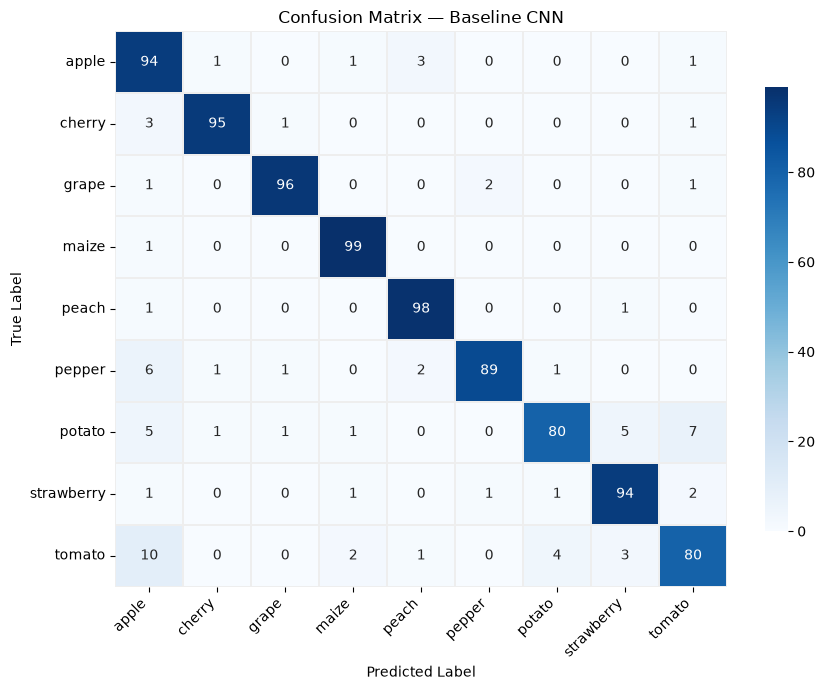

Confusion matrix saved to: /content/eval_results/cnn_confusion_matrix.png

Total misclassified images for Baseline CNN: 75
true_label predicted_label                                                               file_path
     apple           peach  /content/training_data/test/apple/356be10885cb40f0b748cd5a71e388dd.jpg
     apple           peach  /content/training_data/test/apple/c83da6e36b554cbd9b823b530814039a.jpg
     apple          cherry  /content/training_data/test/apple/c2cee54b72f5401994aee1916ddead73.jpg
     apple           peach  /content/training_data/test/apple/ae3d70259dd9402187317fae1a421a80.jpg
     apple          tomato  /content/training_data/test/apple/e621d3f94fef4ec8988e1201f6d4549e.jpg
     apple           maize  /content/training_data/test/apple/3b633079014b45cb9e1b82029151e033.jpg
    cherry           apple /content/training_data/test/cherry/ee5a731554d3401982b00f3ca303ade0.jpg
    cherry           apple /content/training_data/test/cherry/1a4de35bc8934b4796f6cbe

In [12]:
def cnn_predict(filepath):
    image = Image.open(filepath).convert("RGB")
    tensor = cnn_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = cnn_model(tensor)
        pred_idx = logits.argmax(dim=1).item()
    # Index -> class name must use the full 9-class list (the order the
    # checkpoint's output layer was trained on). This matches EVAL_CLASSES
    # once Section 4b has backfilled every class, but would differ from a
    # shorter EVAL_CLASSES if that backfill step is skipped.
    return MODEL_CLASSES[pred_idx]


# CNN has no disease-detection capability (Section 6/13), so it's evaluated on
# crop alone — drop the disease element of each (filepath, crop, disease) triple.
cnn_samples = [(filepath, crop) for filepath, crop, _disease in test_samples]

cnn_results = evaluate_model("Baseline CNN", cnn_predict, cnn_samples, EVAL_CLASSES, progress_every=100)
cnn_metrics = compute_and_report_metrics(
    cnn_results["y_true"], cnn_results["y_pred"], EVAL_CLASSES,
    model_name="Baseline CNN", save_prefix="cnn",
)
cnn_misclassified_df = log_misclassifications(cnn_results, max_rows=30)


## 11. Evaluate SmolVLM (Generative Model)

This step is much slower than the CNN evaluation — each image requires a full
text-generation pass rather than a single forward pass, so evaluating several
hundred images can take a meaningful amount of time on a Colab GPU. Progress
prints every 10 images (elapsed time and an estimated time remaining) so the
cell doesn't look stalled during a long run. If the runtime disconnects partway
through, you'll need to re-run this cell from the start; the CNN results
computed in Section 10 are unaffected as long as the runtime itself isn't
restarted.

Three things get reported here, all from the same single evaluation pass:

1. **Crop confusion matrix** — same axis as the CNN, for direct comparison.
2. **Disease confusion matrix, per crop** — this is the part folder-name-only
   labels couldn't show before. One matrix per crop in `EVAL_CLASSES`, using
   only that crop's ground-truth samples.
3. **Combined crop+disease exact-match accuracy** — the strictest single
   number: did SmolVLM get both right?


Starting evaluation: SmolVLM-256M (LoRA) (900 images)
  [SmolVLM-256M (LoRA)] 10/900 images (1%) — elapsed 13s, est. remaining 1154s
  [SmolVLM-256M (LoRA)] 20/900 images (2%) — elapsed 25s, est. remaining 1114s
  [SmolVLM-256M (LoRA)] 30/900 images (3%) — elapsed 36s, est. remaining 1031s
  [SmolVLM-256M (LoRA)] 40/900 images (4%) — elapsed 46s, est. remaining 996s
  [SmolVLM-256M (LoRA)] 50/900 images (6%) — elapsed 58s, est. remaining 986s
  [SmolVLM-256M (LoRA)] 60/900 images (7%) — elapsed 69s, est. remaining 964s
  [SmolVLM-256M (LoRA)] 70/900 images (8%) — elapsed 82s, est. remaining 971s
  [SmolVLM-256M (LoRA)] 80/900 images (9%) — elapsed 98s, est. remaining 1002s
  [SmolVLM-256M (LoRA)] 90/900 images (10%) — elapsed 111s, est. remaining 1000s
  [SmolVLM-256M (LoRA)] 100/900 images (11%) — elapsed 124s, est. remaining 992s
  [SmolVLM-256M (LoRA)] 110/900 images (12%) — elapsed 141s, est. remaining 1015s
  [SmolVLM-256M (LoRA)] 120/900 images (13%) — elapsed 155s, est. remainin

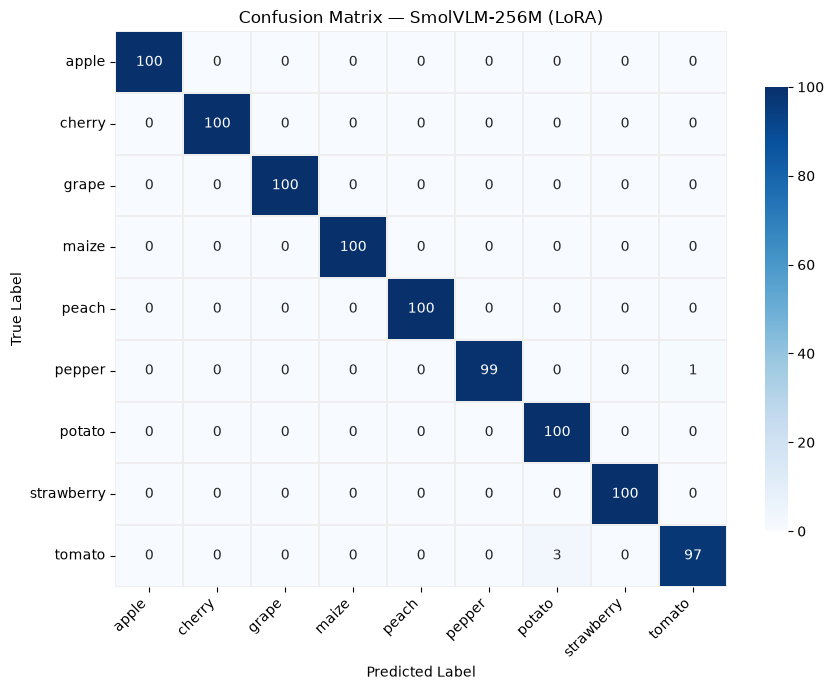

Confusion matrix saved to: /content/eval_results/vlm_confusion_matrix.png

--- Disease detection, per crop ---

EVALUATION RESULTS: Disease Confusion Matrix — Apple (SmolVLM)
Accuracy:        1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1-Score:  1.0000

Per-class report:
                  precision    recall  f1-score   support

       black rot       1.00      1.00      1.00        27
cedar apple rust       1.00      1.00      1.00        18
         healthy       1.00      1.00      1.00        25
            scab       1.00      1.00      1.00        28
     unspecified       1.00      1.00      1.00         2

        accuracy                           1.00       100
       macro avg       1.00      1.00      1.00       100
    weighted avg       1.00      1.00      1.00       100



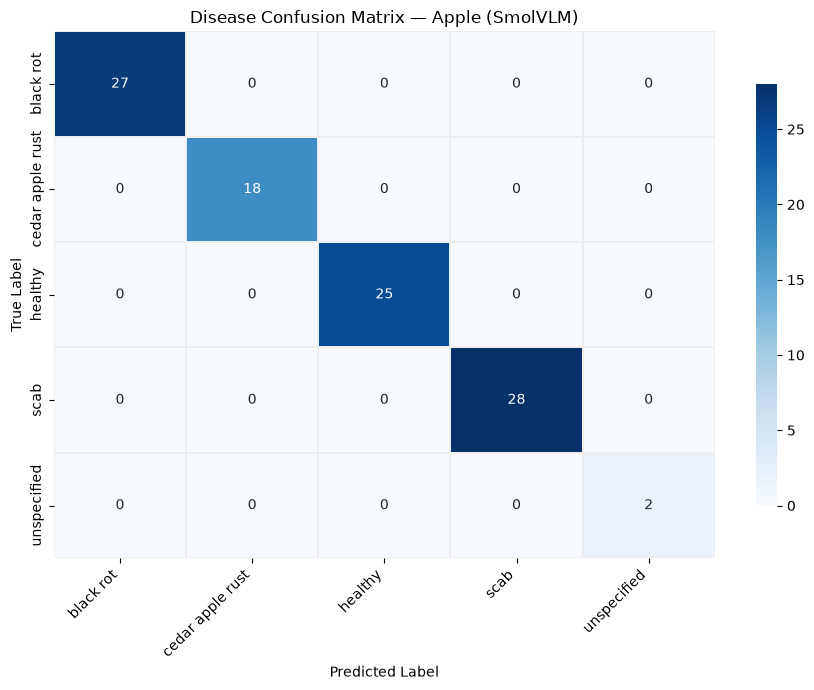

Confusion matrix saved to: /content/eval_results/vlm_disease_apple_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Cherry (SmolVLM)
Accuracy:        1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1-Score:  1.0000

Per-class report:
                precision    recall  f1-score   support

       healthy       1.00      1.00      1.00        56
powdery mildew       1.00      1.00      1.00        42
   unspecified       1.00      1.00      1.00         2

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



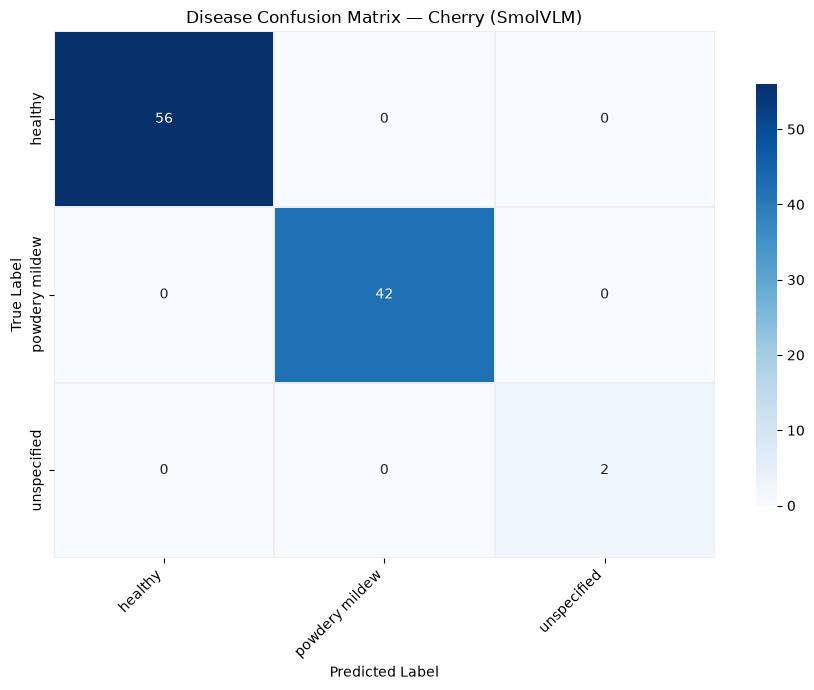

Confusion matrix saved to: /content/eval_results/vlm_disease_cherry_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Grape (SmolVLM)
Accuracy:        0.9900
Macro Precision: 0.9891
Macro Recall:    0.9907
Macro F1-Score:  0.9897

Per-class report:
              precision    recall  f1-score   support

   black rot       1.00      1.00      1.00        26
      blight       1.00      0.96      0.98        27
     healthy       0.96      1.00      0.98        22
 unspecified       1.00      1.00      1.00        25

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



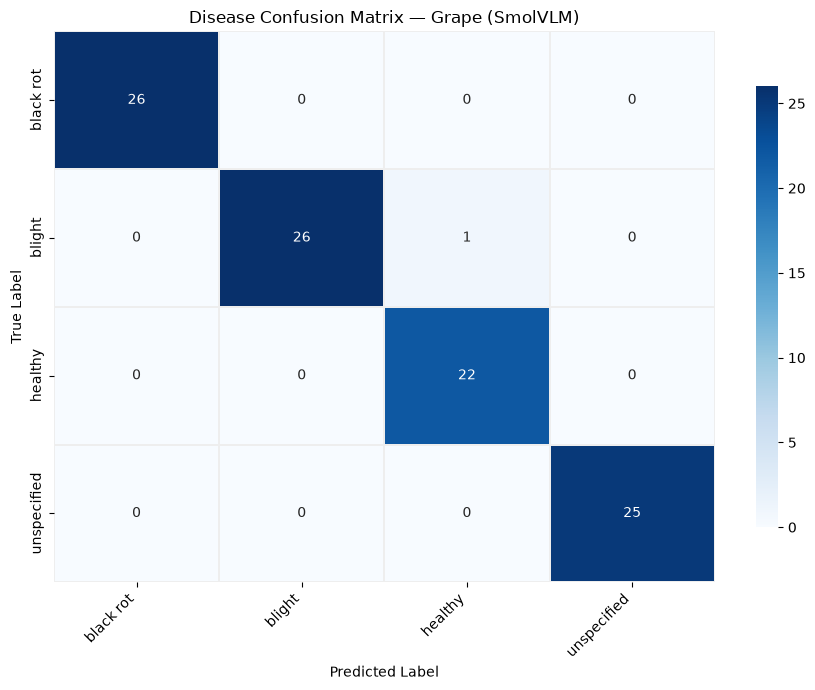

Confusion matrix saved to: /content/eval_results/vlm_disease_grape_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Maize (SmolVLM)
Accuracy:        0.9400
Macro Precision: 0.8800
Macro Recall:    0.9478
Macro F1-Score:  0.9018

Per-class report:
                      precision    recall  f1-score   support

              blight       0.83      0.83      0.83         6
         common rust       1.00      1.00      1.00        24
      gray leaf spot       0.50      1.00      0.67         1
             healthy       1.00      1.00      1.00        17
           leaf spot       0.96      0.90      0.93        29
northern leaf blight       0.86      0.90      0.88        21
                rust       1.00      1.00      1.00         2

            accuracy                           0.94       100
           macro avg       0.88      0.95      0.90       100
        weighted avg       0.95      0.94      0.94       100



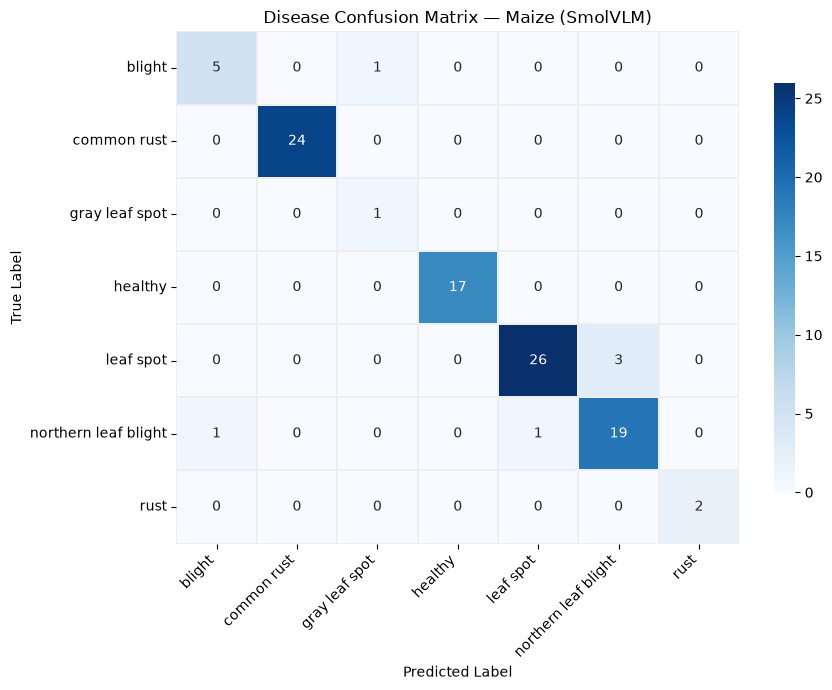

Confusion matrix saved to: /content/eval_results/vlm_disease_maize_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Peach (SmolVLM)
Accuracy:        1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1-Score:  1.0000

Per-class report:
                precision    recall  f1-score   support

bacterial spot       1.00      1.00      1.00        50
       healthy       1.00      1.00      1.00        46
   unspecified       1.00      1.00      1.00         4

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



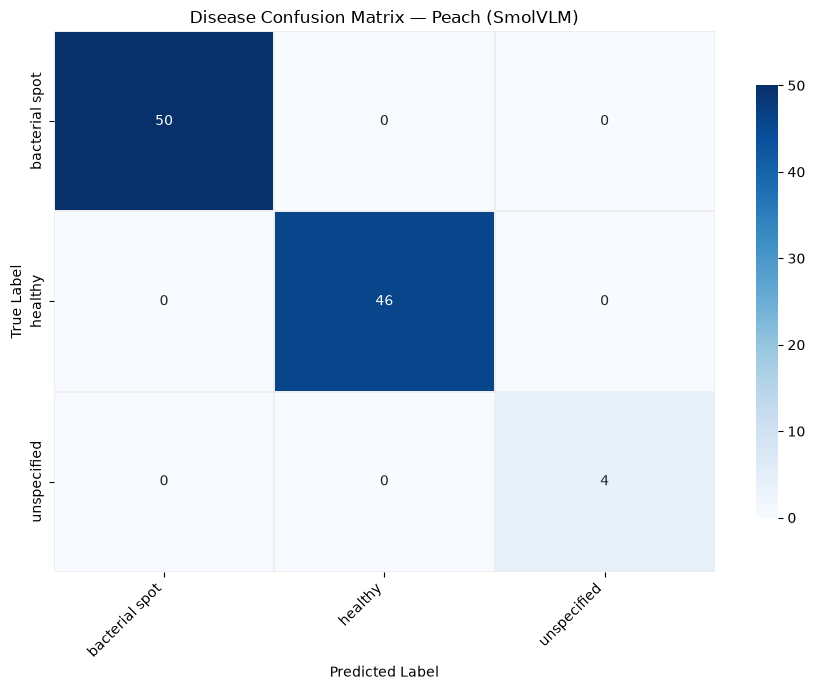

Confusion matrix saved to: /content/eval_results/vlm_disease_peach_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Pepper (SmolVLM)
Accuracy:        0.9900
Macro Precision: 0.7452
Macro Recall:    0.7500
Macro F1-Score:  0.7476

Per-class report:
                precision    recall  f1-score   support

bacterial spot       0.98      1.00      0.99        51
       healthy       1.00      1.00      1.00        47
     leaf spot       0.00      0.00      0.00         1
   unspecified       1.00      1.00      1.00         1

      accuracy                           0.99       100
     macro avg       0.75      0.75      0.75       100
  weighted avg       0.98      0.99      0.99       100



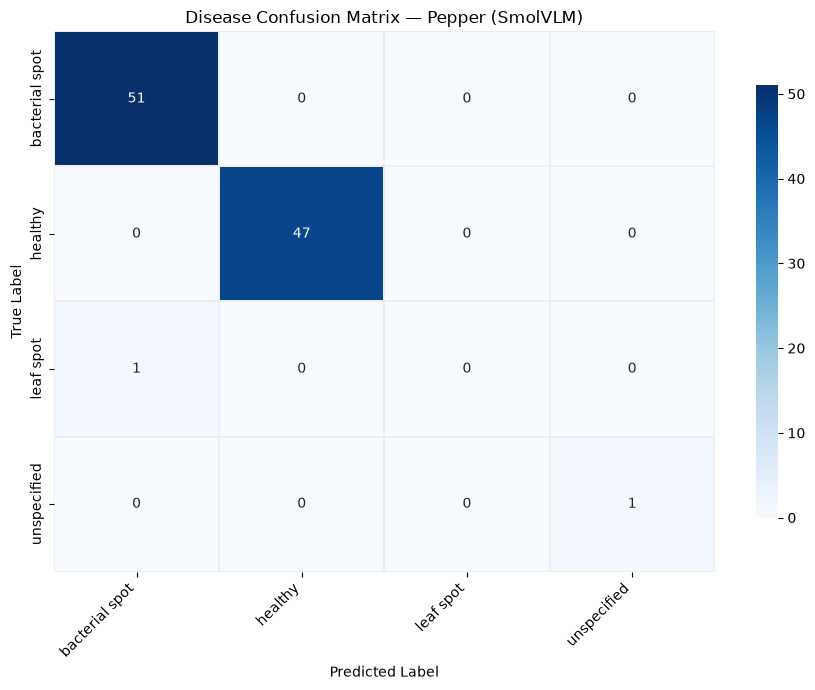

Confusion matrix saved to: /content/eval_results/vlm_disease_pepper_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Potato (SmolVLM)
Accuracy:        0.9900
Macro Precision: 0.9899
Macro Recall:    0.9902
Macro F1-Score:  0.9899

Per-class report:
              precision    recall  f1-score   support

early blight       0.97      1.00      0.98        32
     healthy       1.00      1.00      1.00        34
 late blight       1.00      0.97      0.99        34

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



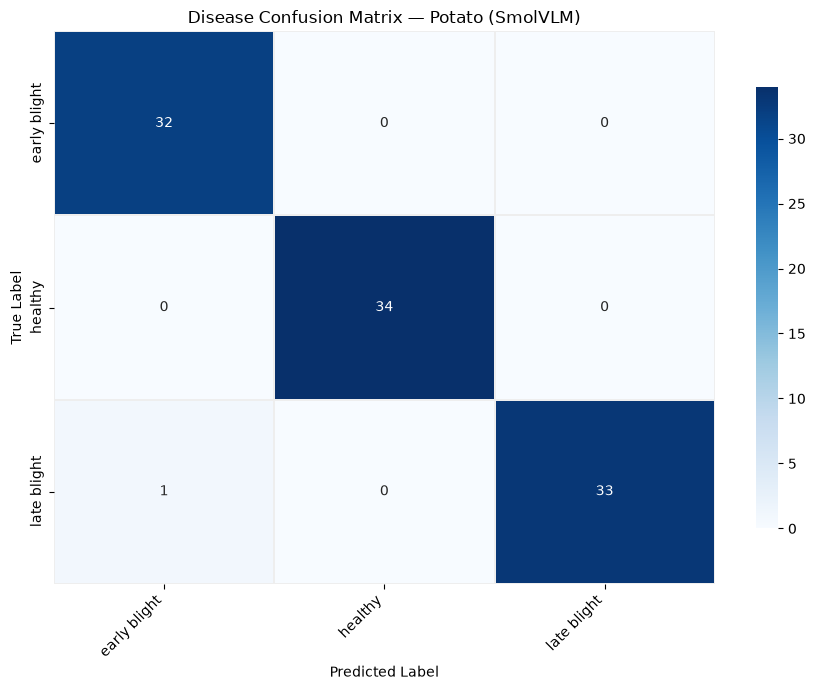

Confusion matrix saved to: /content/eval_results/vlm_disease_potato_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Strawberry (SmolVLM)
Accuracy:        1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1-Score:  1.0000

Per-class report:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        54
 unspecified       1.00      1.00      1.00        46

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



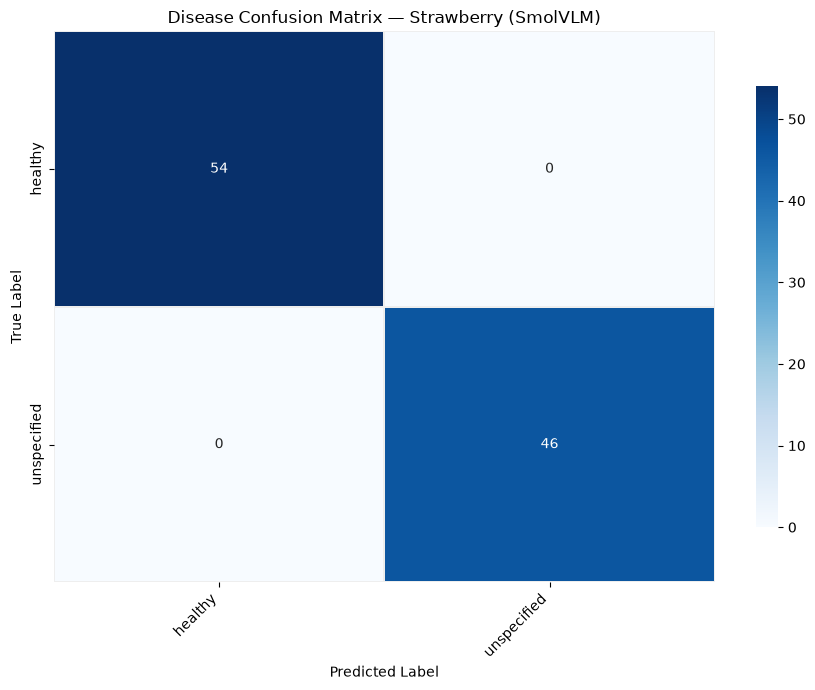

Confusion matrix saved to: /content/eval_results/vlm_disease_strawberry_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — Tomato (SmolVLM)
Accuracy:        0.9400
Macro Precision: 0.7770
Macro Recall:    0.7838
Macro F1-Score:  0.7803

Per-class report:
                        precision    recall  f1-score   support

        bacterial spot       1.00      1.00      1.00        13
          early blight       0.81      0.87      0.84        15
               healthy       1.00      1.00      1.00        17
           late blight       0.96      0.96      0.96        23
             leaf mold       0.00      0.00      0.00         1
    septoria leaf spot       0.95      0.95      0.95        19
           unspecified       0.50      0.50      0.50         2
yellow leaf curl virus       1.00      1.00      1.00        10

              accuracy                           0.94       100
             macro avg       0.78      0.78      0.78       100
          weighted av

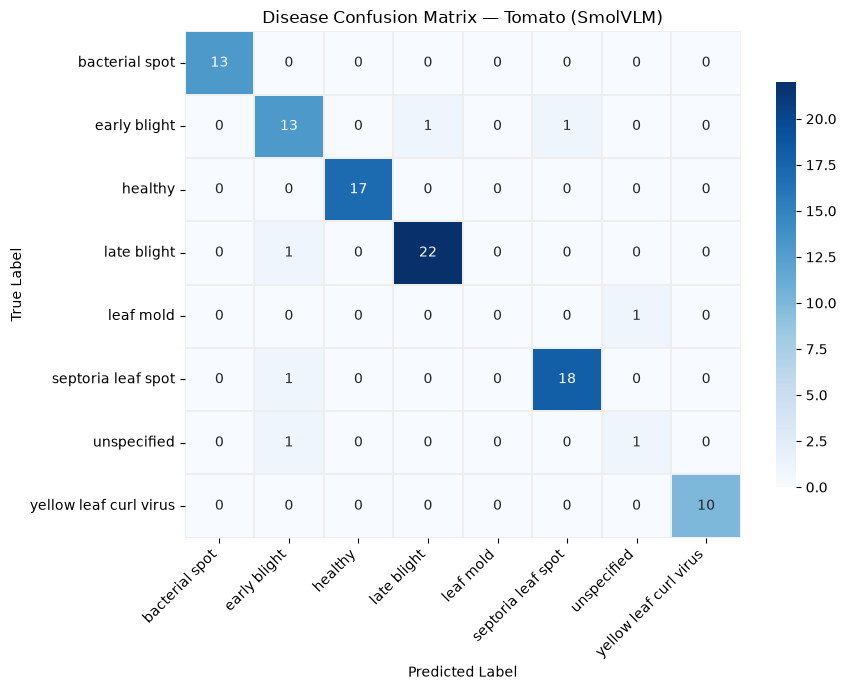

Confusion matrix saved to: /content/eval_results/vlm_disease_tomato_confusion_matrix.png

EVALUATION RESULTS: Disease Confusion Matrix — All Crops Pooled (SmolVLM)
Accuracy:        0.9833
Macro Precision: 0.8955
Macro Recall:    0.9205
Macro F1-Score:  0.9032

Per-class report:
                        precision    recall  f1-score   support

        bacterial spot       0.99      1.00      1.00       114
             black rot       1.00      1.00      1.00        53
                blight       0.97      0.94      0.95        33
      cedar apple rust       1.00      1.00      1.00        18
           common rust       1.00      1.00      1.00        24
          early blight       0.92      0.96      0.94        47
        gray leaf spot       0.50      1.00      0.67         1
               healthy       1.00      1.00      1.00       318
           late blight       0.98      0.96      0.97        57
             leaf mold       0.00      0.00      0.00         1
             lea

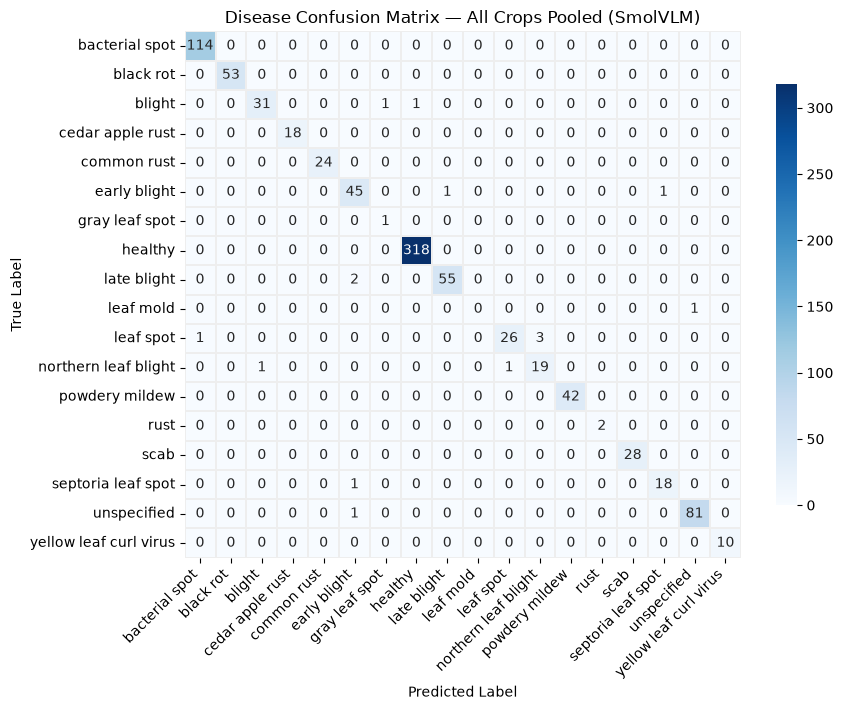

Confusion matrix saved to: /content/eval_results/vlm_disease_overall_confusion_matrix.png

Combined crop+disease exact-match accuracy: 0.9822
Per-crop disease summary saved to: /content/eval_results/vlm_disease_summary_per_crop.csv

Per-crop disease summary:
        crop  accuracy  macro_precision  macro_recall  macro_f1  n_samples
       apple    1.0000           1.0000        1.0000    1.0000        100
      cherry    1.0000           1.0000        1.0000    1.0000        100
       grape    0.9900           0.9891        0.9907    0.9897        100
       maize    0.9400           0.8800        0.9478    0.9018        100
       peach    1.0000           1.0000        1.0000    1.0000        100
      pepper    0.9900           0.7452        0.7500    0.7476        100
      potato    0.9900           0.9899        0.9902    0.9899        100
  strawberry    1.0000           1.0000        1.0000    1.0000        100
      tomato    0.9400           0.7770        0.7838    0.7803   

In [13]:
vlm_results = evaluate_vlm_model("SmolVLM-256M (LoRA)", test_samples, progress_every=10)

print("\n--- Crop classification (same axis as the CNN, for direct comparison) ---")
vlm_metrics = compute_and_report_metrics(
    vlm_results["y_crop_true"], vlm_results["y_crop_pred"], EVAL_CLASSES,
    model_name="SmolVLM-256M (LoRA)", save_prefix="vlm",
    title="Confusion Matrix — SmolVLM-256M (LoRA)",
)

print("\n--- Disease detection, per crop ---")
vlm_disease_summary_df, vlm_combined_exact_match_accuracy = compute_and_report_disease_metrics_per_crop(
    vlm_results, EVAL_CLASSES, save_prefix="vlm"
)
print("\nPer-crop disease summary:")
print(vlm_disease_summary_df.round(4).to_string(index=False))

vlm_misclassified_df = log_misclassifications(
    {"model_name": "SmolVLM-256M (LoRA)", "misclassified": vlm_results["misclassified"]},
    max_rows=30,
)


--- Combined crop+disease (joint label), full metric set ---

EVALUATION RESULTS: Confusion Matrix — Crop+Disease Joint (SmolVLM)
Accuracy:        0.9822
Macro Precision: 0.9037
Macro Recall:    0.9178
Macro F1-Score:  0.9084

Per-class report:
                                 precision    recall  f1-score   support

              apple - black rot       1.00      1.00      1.00        27
       apple - cedar apple rust       1.00      1.00      1.00        18
                apple - healthy       1.00      1.00      1.00        25
                   apple - scab       1.00      1.00      1.00        28
            apple - unspecified       1.00      1.00      1.00         2
               cherry - healthy       1.00      1.00      1.00        56
        cherry - powdery mildew       1.00      1.00      1.00        42
           cherry - unspecified       1.00      1.00      1.00         2
              grape - black rot       1.00      1.00      1.00        26
                 grape -

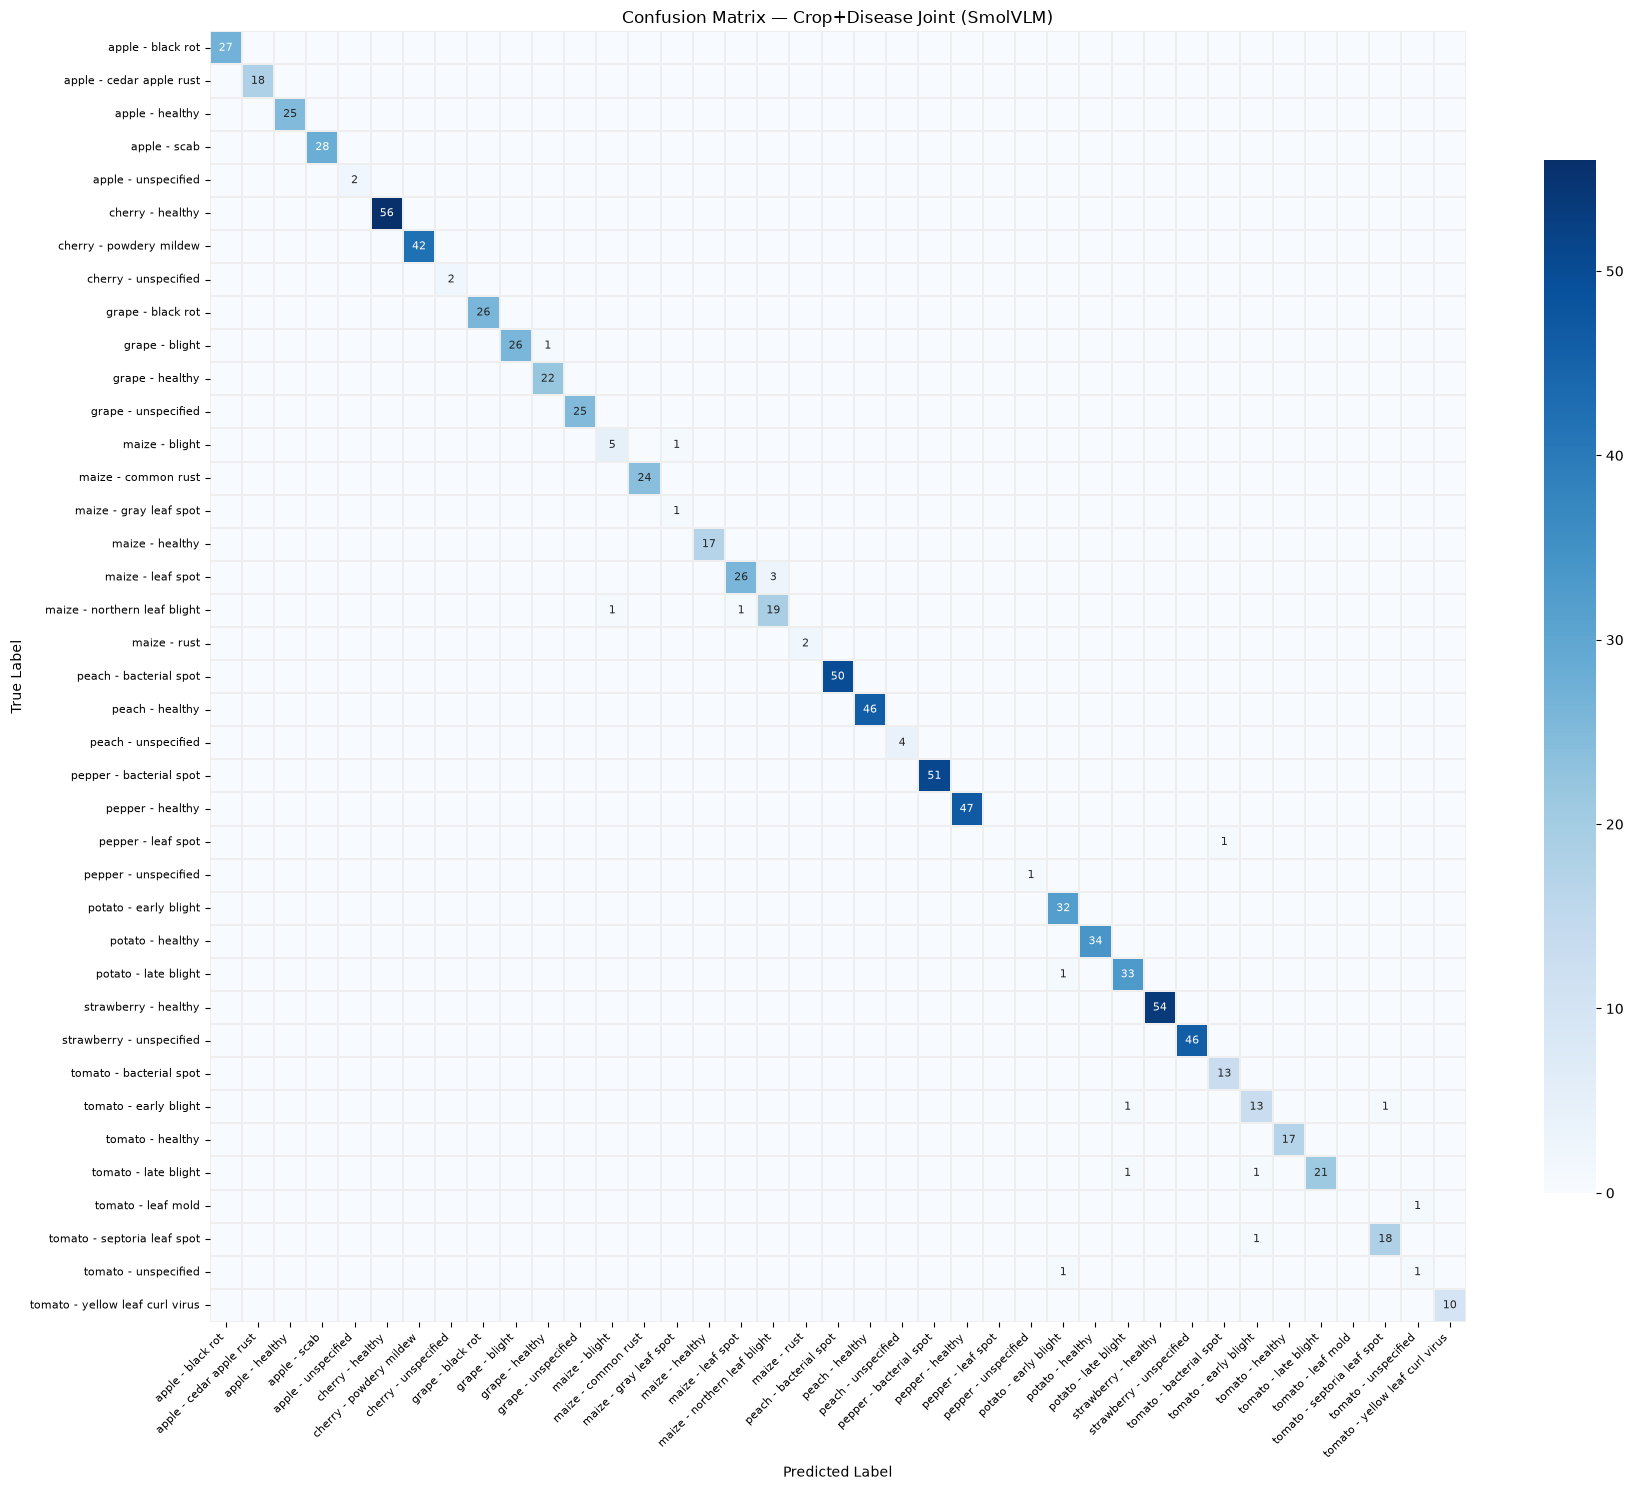

Confusion matrix saved to: /content/eval_results/vlm_joint_confusion_matrix.png

Joint-label accuracy: 0.9822
Earlier exact-match accuracy: 0.9822


In [14]:
# Joint crop+disease label — gives macro precision/recall/F1 and a real
# confusion matrix, not just a bare accuracy number.
y_joint_true = [f"{c} - {d}" for c, d in zip(vlm_results["y_crop_true"], vlm_results["y_disease_true"])]
y_joint_pred = [f"{c} - {d}" for c, d in zip(vlm_results["y_crop_pred"], vlm_results["y_disease_pred"])]

joint_classes = sorted(set(y_joint_true))  # ground-truth joint classes only

print("--- Combined crop+disease (joint label), full metric set ---")
vlm_joint_metrics = compute_and_report_metrics(
    y_joint_true, y_joint_pred, joint_classes,
    model_name="SmolVLM-256M (LoRA) — Crop+Disease Joint",
    save_prefix="vlm_joint",
    title="Confusion Matrix — Crop+Disease Joint (SmolVLM)",
    # ~34 joint classes overwhelms the default sizing (every empty cell's "0"
    # competes with the real counts, tick labels overlap). A bigger canvas,
    # blanked-out zero cells, and smaller tick text keep the block-diagonal
    # shape (each crop's diseases only confuse within that crop) legible.
    figsize=(18, 15),
    annot_zeros=False,
    tick_fontsize=8,
)

# Sanity check: should exactly match the earlier both_correct figure
print(f"\nJoint-label accuracy: {vlm_joint_metrics['accuracy']:.4f}")
print(f"Earlier exact-match accuracy: {vlm_combined_exact_match_accuracy:.4f}")
assert abs(vlm_joint_metrics["accuracy"] - vlm_combined_exact_match_accuracy) < 1e-9


## 12. Side-by-Side Model Comparison

Model Comparison Summary (crop classification)
                     accuracy  macro_precision  macro_recall  macro_f1  n_samples
model_name                                                                       
Baseline CNN           0.9167           0.9204        0.9167    0.9166        900
SmolVLM-256M (LoRA)    0.9956           0.9956        0.9956    0.9956        900

SmolVLM combined crop+disease exact-match accuracy: 0.9822
(Not shown above — the CNN has no disease output, so there's nothing to compare it against.)

Comparison table saved to: /content/eval_results/model_comparison_summary.csv


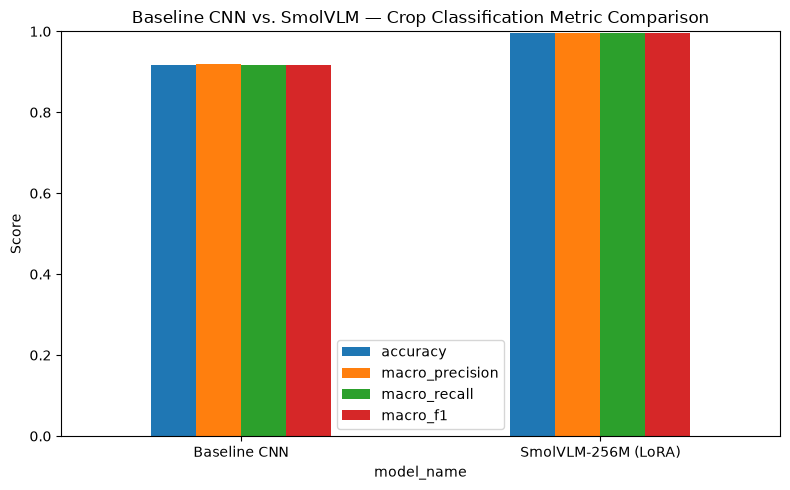

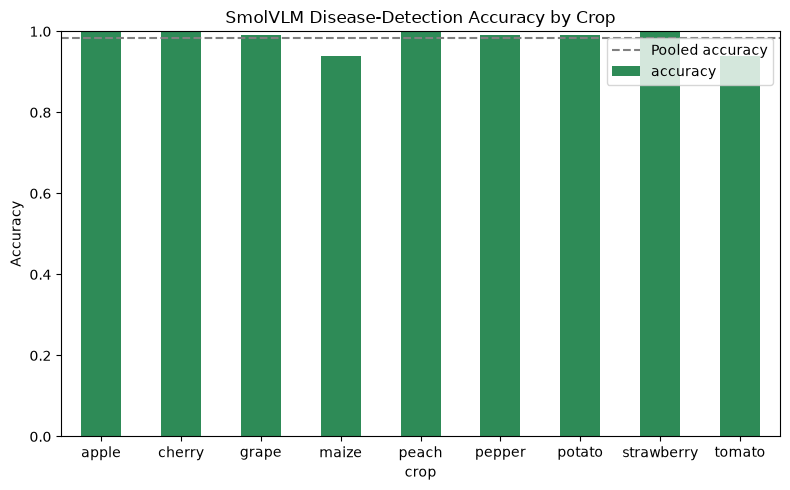

In [15]:
comparison_df = pd.DataFrame([cnn_metrics, vlm_metrics]).set_index("model_name")
comparison_df = comparison_df[["accuracy", "macro_precision", "macro_recall", "macro_f1", "n_samples"]]

print("Model Comparison Summary (crop classification)")
print(comparison_df.round(4).to_string())
print(f"\nSmolVLM combined crop+disease exact-match accuracy: {vlm_combined_exact_match_accuracy:.4f}")
print("(Not shown above — the CNN has no disease output, so there's nothing to compare it against.)")

comparison_path = RESULTS_DIR / "model_comparison_summary.csv"
comparison_df.to_csv(comparison_path)
print(f"\nComparison table saved to: {comparison_path}")

ax = comparison_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].plot(
    kind="bar", figsize=(8, 5), rot=0
)
ax.set_title("Baseline CNN vs. SmolVLM — Crop Classification Metric Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison_chart.png", dpi=150)
plt.show()

# SmolVLM-only: disease accuracy by crop, so the report can show at a glance
# where disease detection is strong vs. weak, rather than just one pooled number.
per_crop_only = vlm_disease_summary_df[vlm_disease_summary_df["crop"] != "ALL (pooled)"]
ax2 = per_crop_only.set_index("crop")["accuracy"].plot(kind="bar", figsize=(8, 5), rot=0, color="seagreen")
ax2.axhline(
    vlm_disease_summary_df.loc[vlm_disease_summary_df["crop"] == "ALL (pooled)", "accuracy"].iloc[0],
    color="gray", linestyle="--", label="Pooled accuracy",
)
ax2.set_title("SmolVLM Disease-Detection Accuracy by Crop")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "vlm_disease_accuracy_by_crop_chart.png", dpi=150)
plt.show()


## 13. Notes for the Final Group Report

- `eval_results/` now contains, per model:
  - **CNN:** `cnn_confusion_matrix.png`, `baseline_cnn_misclassified.csv`.
  - **SmolVLM:** `vlm_confusion_matrix.png` (crop), one
    `vlm_disease_<crop>_confusion_matrix.png` per crop, plus
    `vlm_disease_overall_confusion_matrix.png` (pooled), a
    `vlm_disease_summary_per_crop.csv` with per-crop accuracy/F1, and
    `smolvlm-256m_(lora)_misclassified.csv` (now includes both crop and
    disease predictions per image, plus the raw generated text).
  - **Comparison:** `model_comparison_summary.csv`/`.png` (crop only — the CNN
    has nothing to compare on disease) and `vlm_disease_accuracy_by_crop_chart.png`.
- For the Error Analysis section, cross-reference `*_misclassified.csv` file paths
  against the source images to identify recurring failure patterns (e.g. visually
  similar diseases, poor lighting, classes the crop keyword heuristic under-detects,
  or diseases that fall outside a crop's known vocabulary and get logged as `"other"`).
- **Methodology note worth stating explicitly in the report:** evaluation covers 5 of
  the CNN's 9 trained classes (`cherry`, `peach`, `pepper`, `strawberry` were excluded
  due to insufficient test data). If the CNN ever predicts one of the excluded classes
  for a test image, it still shows up as a misclassification and as an extra column in
  the confusion matrix — it is not silently discarded.
- **Disease labels are folder-derived, not expert-verified** — check `label_source`
  in `labels_registry.jsonl` (currently always `"foldername"`). Treat disease accuracy
  as a proxy for how well SmolVLM reproduces the dataset's own labeling scheme, not as
  clinical diagnostic accuracy, and say so in the report.
- If GPU memory is limited, restart the runtime between the CNN and SmolVLM sections
  (`Runtime > Restart session`) and re-run only the required cells.
